# EU Progress Report — Criticism Scoring Pipeline

## Overview
This notebook measures the tone and intensity of EU criticism in annual Progress Reports covering ten EU candidate and neighbourhood countries (2019–2025). The goal is to quantify, compare, and model variation in how harshly the EU frames democratic governance failures across countries and policy domains.

---

## Data
EU Progress Reports were scraped as plain text and segmented into paragraphs of 50–500 words, yielding ~26,700 paragraph-level observations across 10 countries and 7 years. Each paragraph is the unit of analysis.

---

## NLP Methodology

### Approach: EPU-style dictionary scoring
Following Baker, Bloom & Davis (2016), paragraphs are scored by counting hits from a custom keyword dictionary, normalised per 1,000 words. This approach was chosen over machine learning alternatives for three reasons: (1) interpretability — every score is traceable to specific words; (2) no labelled training data is required; (3) the EU's institutional register is stable and rule-governed, making dictionary methods reliable.

### Criticism dictionary
A custom two-tier lexicon was built to distinguish the EU's rhetorical registers:

- **Hard criticism** (`CRITICISM_HARD`) — unambiguous failure and regression language: *failed, backsliding, violation, state capture, systemic, obstruction, impunity, deterioration, stagnation, lack of, shortcomings, inadequate, insufficient*. These terms signal explicit condemnation.
- **Soft criticism** (`CRITICISM_SOFT`) — hedged concern language: *concerns, challenges, delays, limited, persistent, remain, issues, risks, needs to be, has yet to*. These are common in EU bureaucratic text and carry weaker signal individually.

Scoring uses substring matching on lowercased text (catches multi-word phrases). The **severity ratio** (hard_p1k / soft_p1k) captures the balance between the two registers — a high ratio means the EU is condemning rather than merely flagging.

### Topic tagging
Five policy domains are tagged via keyword matching (no ML):
| Topic | Key terms |
|---|---|
| Judiciary / rule of law | judicial, court, rule of law, independence, prosecution |
| Corruption | corruption, fraud, bribery, anti-corruption, integrity |
| Public administration | public administration, civil service, governance, capacity |
| Political functioning | political, parliament, opposition, dialogue, elections |
| Economy / market | economic, market, growth, employment, investment |

A paragraph can belong to multiple topics simultaneously.

---

## Regression design (Spec B)
Logistic regression (hard/soft flag as binary DV) and OLS (severity ratio) are run on the **six countries with full 2019–2025 coverage**: Albania, Kosovo, Montenegro, North Macedonia, Serbia, Türkiye. **North Macedonia** serves as the reference country (mid-pack Western Balkans EU candidate). Standard errors are clustered by country.

**DVs:**
- M1 `hard_flag` — any hard criticism in paragraph (logit)
- M2 `soft_flag` — any soft criticism in paragraph (logit)
- M3 `severity_ratio` — hard / soft ratio, paragraphs with soft criticism only (OLS)

**IVs:** topic dummies + year (linear trend, centred) + country fixed effects

## Step 1 — Build paragraph corpus
Loads raw `.txt` files from `scraped/raw/`, strips page markers, detects paragraph boundaries (double trailing space or sentence-end + newline signals), and filters to paragraphs between 50 and 500 words. Filenames encode country and year (e.g. `kosovo_2023_raw.txt`).

In [ ]:
import sys, pathlib

# Locate repo root (contains src/) regardless of where the kernel was launched
_root = next(p for p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent] if (p / "src").exists())
sys.path.insert(0, str(_root / "src"))


In [1]:
from corpus import build_corpus

df = build_corpus("scraped/raw", min_words=50, max_words=500)

print(f"Total paragraphs : {len(df):,}")
print(f"Countries        : {sorted(df['country'].unique())}")
print(f"Years            : {sorted(df['year'].unique())}")
df.head(3)

  Albania                   2019  →  444 paragraphs
  Albania                   2020  →  547 paragraphs
  Albania                   2021  →  576 paragraphs
  Albania                   2022  →  538 paragraphs
  Albania                   2023  →  591 paragraphs
  Albania                   2024  →  363 paragraphs
  Albania                   2025  →  376 paragraphs
  Bosnia And Herzegovina    2020  →  497 paragraphs
  Bosnia And Herzegovina    2021  →  519 paragraphs
  Bosnia And Herzegovina    2022  →  548 paragraphs
  Bosnia And Herzegovina    2023  →  591 paragraphs
  Bosnia And Herzegovina    2024  →  368 paragraphs
  Bosnia And Herzegovina    2025  →  394 paragraphs
  Georgia                   2023  →  522 paragraphs
  Georgia                   2024  →  362 paragraphs
  Georgia                   2025  →  290 paragraphs
  Kosovo                    2019  →  395 paragraphs
  Kosovo                    2020  →  481 paragraphs
  Kosovo                    2021  →  457 paragraphs
  Kosovo    

,country,year,paragraph_id,paragraph_text,word_count
0,Albania,2019,0,Democracy 6 2.1.2. Public administration re...,72
1,Albania,2019,1,Albania has continued to implement the Stabili...,115
2,Albania,2019,2,Parliamentary activities were affected by a pr...,94


## Step 2 — Score paragraphs
Applies the `CRITICISM_HARD` and `CRITICISM_SOFT` keyword lists to each paragraph using substring matching on lowercased text. Counts are normalised per 1,000 words to control for paragraph length. The severity ratio (hard / soft) is undefined and set to `NaN` when no soft criticism is present.

In [2]:
from score import score_corpus

df_scored = score_corpus(df)

print(f"Paragraphs with any hard criticism : {(df_scored['criticism_hard_p1k'] > 0).sum():,}")
print(f"Paragraphs with any soft criticism : {(df_scored['criticism_soft_p1k'] > 0).sum():,}")
print(f"Paragraphs with severity score     : {df_scored['severity_ratio'].notna().sum():,}")
df_scored[["country","year","paragraph_id","word_count",
           "criticism_hard_p1k","criticism_soft_p1k","severity_ratio"]].head(5)

Paragraphs with any hard criticism : 4,620
Paragraphs with any soft criticism : 17,833
Paragraphs with severity score     : 17,833


,country,year,paragraph_id,word_count,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,0,72,0.0,0.0,NaN
1,Albania,2019,1,115,0.0,0.0,NaN
2,Albania,2019,2,94,0.0,0.0,NaN
3,Albania,2019,3,95,0.0,0.0,NaN
4,Albania,2019,4,171,0.0,0.0,NaN


## Step 3 — Aggregate to country-year level
Takes the unweighted mean of each score across all paragraphs within a country-year. Per-1k normalisation already accounts for paragraph length, so additional word-count weighting would be redundant. Produces the `agg` dataframe (57 rows: one per country-year).

In [3]:
from score import aggregate_country_year

agg = aggregate_country_year(df_scored)
print(agg.to_string(index=False))

               country  year  criticism_hard_p1k  criticism_soft_p1k  severity_ratio
               Albania  2019              1.4618             21.3927          0.0723
               Albania  2020              1.2345             20.1961          0.0657
               Albania  2021              1.2019             19.1759          0.0561
               Albania  2022              1.2767             22.1027          0.0681
               Albania  2023              1.5470             25.5129          0.0670
               Albania  2024              1.3549             24.3694          0.0567
               Albania  2025              2.0698             27.4993          0.0887
Bosnia And Herzegovina  2020              3.8650             28.1994          0.1830
Bosnia And Herzegovina  2021              3.8327             28.8028          0.1426
Bosnia And Herzegovina  2022              3.4687             27.8572          0.1653
Bosnia And Herzegovina  2023              3.1847             28.5

### Step 3b — Map: hard criticism and severity ratio (2025)

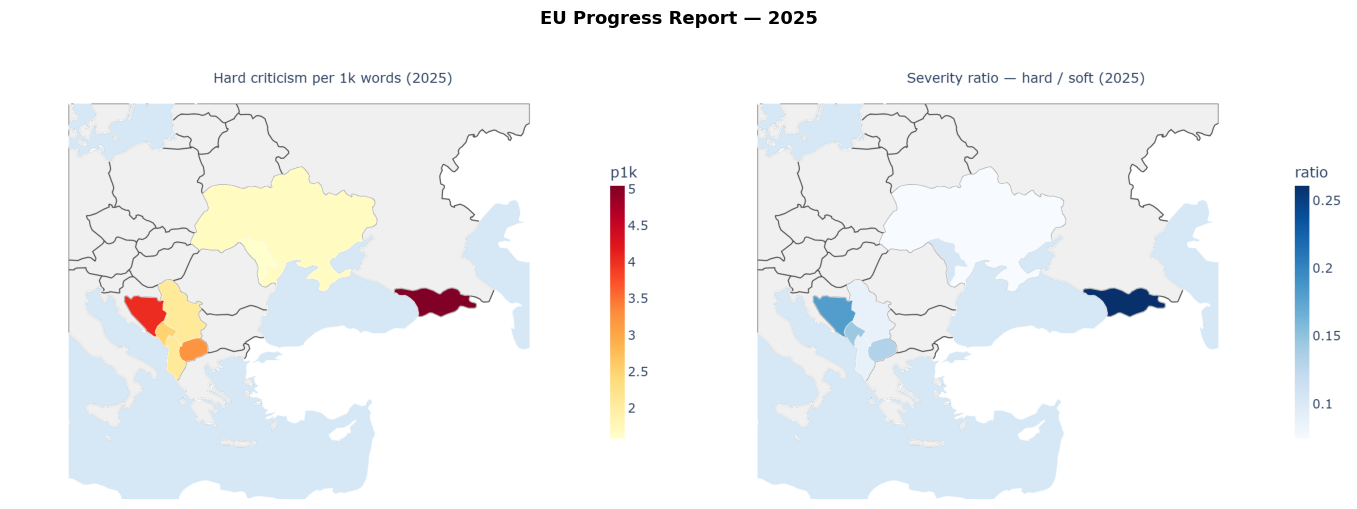

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

# ── 2025 data ─────────────────────────────────────────────────────────────────
agg_2025 = agg[agg["year"] == 2025].copy()

iso3 = {
    "Albania":                "ALB",
    "Bosnia And Herzegovina": "BIH",
    "Georgia":                "GEO",
    "Kosovo":                 "XKX",
    "Moldova":                "MDA",
    "Montenegro":             "MNE",
    "North Macedonia":        "MKD",
    "Serbia":                 "SRB",
    "Turkiye":                "TUR",
    "Ukraine":                "UKR",
}
agg_2025["iso3"] = agg_2025["country"].map(iso3)

# ── geo settings — wide enough to include Turkey and Georgia ──────────────────
geo = dict(
    scope="europe",
    resolution=50,
    showcoastlines=True,  coastlinecolor="white",
    showland=True,        landcolor="#f0f0f0",
    showocean=True,       oceancolor="#d6e8f5",
    showlakes=False,
    lataxis_range=[33, 55],
    lonaxis_range=[13, 50],
)

def make_map(locations, z, text, colorscale, colorbar_title, title):
    fig = go.Figure(go.Choropleth(
        locations=locations,
        z=z,
        text=text,
        locationmode="ISO-3",
        colorscale=colorscale,
        colorbar=dict(title=colorbar_title, thickness=14, len=0.75),
        hovertemplate="%{text}: %{z:.3f}<extra></extra>",
        marker_line_color="white",
        marker_line_width=0.5,
    ))
    fig.update_layout(
        title=dict(text=title, x=0.5, font_size=13),
        geo=geo,
        height=420, width=620,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig

fig_hard = make_map(
    agg_2025["iso3"], agg_2025["criticism_hard_p1k"], agg_2025["country"],
    "YlOrRd", "p1k", "Hard criticism per 1k words (2025)"
)
fig_sev = make_map(
    agg_2025["iso3"], agg_2025["severity_ratio"], agg_2025["country"],
    "Blues", "ratio", "Severity ratio — hard / soft (2025)"
)

# ── render as static PNGs and display side by side via matplotlib ─────────────
img_hard = mpimg.imread(io.BytesIO(fig_hard.to_image(format="png", scale=2)))
img_sev  = mpimg.imread(io.BytesIO(fig_sev.to_image(format="png", scale=2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, img in zip(axes, [img_hard, img_sev]):
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("EU Progress Report — 2025", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


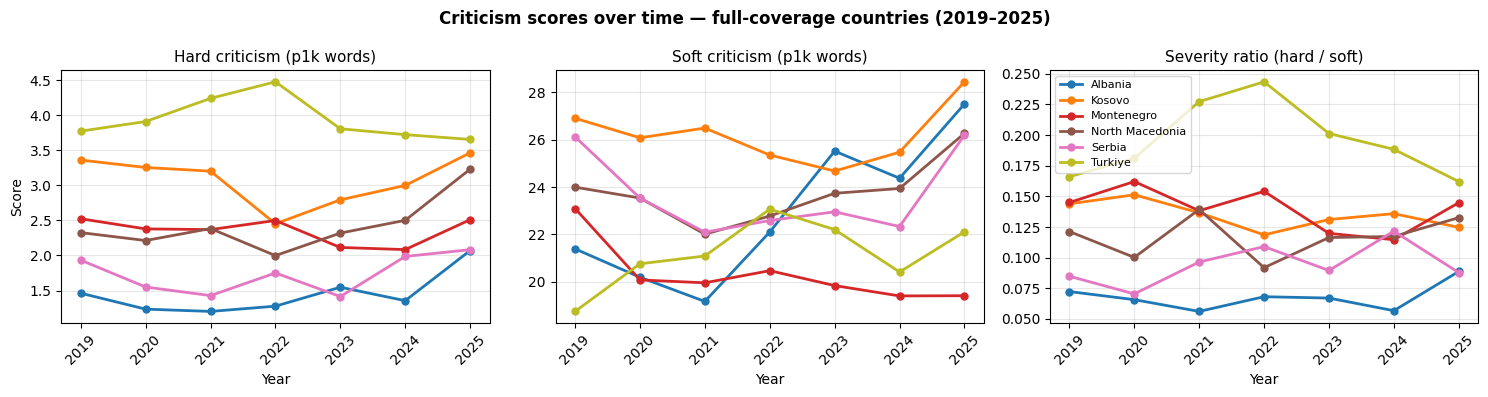

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

full_coverage = ["Albania", "Kosovo", "Montenegro", "North Macedonia", "Serbia", "Turkiye"]
sub = agg[agg["country"].isin(full_coverage)].sort_values("year")

colors = {c: cm.tab10(i / len(full_coverage)) for i, c in enumerate(full_coverage)}

panels = [
    ("criticism_hard_p1k",  "Hard criticism (p1k words)"),
    ("criticism_soft_p1k",  "Soft criticism (p1k words)"),
    ("severity_ratio",      "Severity ratio (hard / soft)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (col, ylabel) in zip(axes, panels):
    for country, grp in sub.groupby("country"):
        ax.plot(grp["year"], grp[col], marker="o", linewidth=2,
                markersize=5, color=colors[country], label=country)
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Score")
axes[2].legend(fontsize=8, loc="upper left")

plt.suptitle("Criticism scores over time — full-coverage countries (2019–2025)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 4 — Tag topics
Assigns each paragraph to one or more of five policy domains using keyword substring matching. A paragraph can belong to multiple topics simultaneously (mean = 1.18 topics per paragraph). Topic assignment is used as independent variables in the regression — they capture *what* the EU is writing about, allowing the regression to separate topic composition effects from residual country effects.

In [6]:
from score import tag_topics

df_scored = tag_topics(df_scored)

topic_cols = [c for c in df_scored.columns if c.startswith("topic_")]
topic_counts = df_scored[topic_cols].sum().rename(lambda c: c.replace("topic_", ""))

print("Paragraphs flagged per topic (corpus-wide):")
print(topic_counts.to_string())
print()
print(f"Paragraphs with at least one topic : {df_scored[topic_cols].any(axis=1).sum():,}")
print(f"Paragraphs with no topic match     : {(~df_scored[topic_cols].any(axis=1)).sum():,}")
print(f"Mean topics per paragraph          : {df_scored[topic_cols].sum(axis=1).mean():.2f}")

Paragraphs flagged per topic (corpus-wide):
judiciary_rule_of_law                5613
corruption_anti_corruption           3410
public_administration_governance     4110
political_functioning               10847
economy_market                       7594

Paragraphs with at least one topic : 19,766
Paragraphs with no topic match     : 6,998
Mean topics per paragraph          : 1.18


## Step 5 — Spec B regression

Three models, same specification, different dependent variables:

| Model | DV | Estimator | N |
|---|---|---|---|
| M1 | `hard_flag` (0/1) | Logit | 19,910 |
| M2 | `soft_flag` (0/1) | Logit | 19,910 |
| M3 | `severity_ratio` | OLS | ~11,500 (paragraphs with soft criticism) |

**Sample:** Six countries with complete 2019–2025 coverage only — this avoids the unbalanced panel problem where late-entry countries (Georgia, Moldova, Ukraine, Bosnia) are observed only in 2023–2025 and their fixed effects would conflate country-level and period-level variation.

**Reference:** North Macedonia — a mid-pack Western Balkans EU candidate, the most neutral and defensible baseline.

**Standard errors:** Clustered by country (10 clusters in the full sample, 6 here) to account for within-country correlation across paragraphs.

**Year:** Entered as a centred linear trend (median = 2022). The coefficient captures whether hard/soft criticism has systematically increased or decreased over time.

In [7]:
import warnings, re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ── sample: full 2019-2025 coverage only ─────────────────────────────────────
full_coverage = ["Albania", "Kosovo", "Montenegro", "North Macedonia", "Serbia", "Turkiye"]

reg = df_scored[df_scored["country"].isin(full_coverage)].copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
reg["soft_flag"] = (reg["criticism_soft_p1k"] > 0).astype(int)
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"] = reg["year"] - reg["year"].median()

topic_terms = " + ".join(topic_cols)
rhs         = f"{topic_terms} + year_c + C(country, Treatment('North Macedonia'))"
ck          = {"cov_type": "cluster", "cov_kwds": {"groups": reg["country"]}}
reg_sev     = reg[reg["severity_ratio"].notna()].copy()
ck_sev      = {"cov_type": "cluster", "cov_kwds": {"groups": reg_sev["country"]}}

# ── fit ───────────────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m1 = smf.logit(f"hard_flag ~ {rhs}", data=reg).fit(disp=False, **ck)
    m2 = smf.logit(f"soft_flag ~ {rhs}", data=reg).fit(disp=False, **ck)
    m3 = smf.ols(f"severity_ratio ~ {rhs}", data=reg_sev).fit(**ck_sev)

# ── helpers ───────────────────────────────────────────────────────────────────
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def extract(model, label, exponentiate):
    idx  = [i for i in model.params.index if "country" in i or
             i.startswith("topic_") or i.startswith("year_c")]
    vals = np.exp(model.params[idx]) if exponentiate else model.params[idx]
    pvs  = model.pvalues[idx]
    def clean(s):
        m = re.search(r"T\.(.+?)\]", s)
        if m: return m.group(1)
        return s.replace("topic_","").replace("_"," ").replace("year c","year trend")
    return pd.Series(
        [f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvs)],
        index=[clean(i) for i in idx],
        name=label
    )

# ── print tables ──────────────────────────────────────────────────────────────
print(f"n = {len(reg):,} paragraphs  |  countries: {', '.join(full_coverage)}")
print(f"Reference: North Macedonia  |  SEs clustered by country\n")
print("* p<.05   ** p<.01   *** p<.001\n")

tbl = pd.concat([
    extract(m1, "M1 hard_flag (OR)",    exponentiate=True),
    extract(m2, "M2 soft_flag (OR)",    exponentiate=True),
    extract(m3, "M3 severity_ratio (β)", exponentiate=False),
], axis=1)

topic_rows   = [i for i in tbl.index if i not in full_coverage and i != "year trend"]
country_rows = [i for i in tbl.index if i in full_coverage]

print("── Topics & time ──")
print(tbl.loc[topic_rows + ["year trend"]].to_string())
print()
print("── Country fixed effects (vs North Macedonia) ──")
print(tbl.loc[country_rows].to_string())

n = 19,910 paragraphs  |  countries: Albania, Kosovo, Montenegro, North Macedonia, Serbia, Turkiye
Reference: North Macedonia  |  SEs clustered by country

* p<.05   ** p<.01   *** p<.001

── Topics & time ──
                                 M1 hard_flag (OR) M2 soft_flag (OR) M3 severity_ratio (β)
judiciary rule of law                     1.921***            1.156*              0.089***
corruption anti corruption                1.637***          1.481***               0.049**
public administration governance            1.107*           1.296**                -0.013
political functioning                      1.242**          1.110***                 0.014
economy market                              0.878*             1.041               -0.026*
year trend                                   1.002             1.026                 0.001

── Country fixed effects (vs North Macedonia) ──
           M1 hard_flag (OR) M2 soft_flag (OR) M3 severity_ratio (β)
Albania             0.605***       

### Step 5b — Spec B summary: fitted probabilities and topic effects

Odds ratios are precise but not immediately intuitive. The table below converts M1 predictions into **average fitted hard-flag probabilities per country** — the share of paragraphs the model expects to contain hard criticism, holding topic composition and year constant at each country's observed distribution. This sits alongside the raw observed rate so you can see how much of the country difference the model accounts for.

Hard-flag probability per country (M1, North Macedonia reference)
                Observed rate Fitted rate (M1) Difference
country                                                  
Turkiye                 24.2%            24.2%      -0.0%
Kosovo                  20.9%            20.9%       0.0%
North Macedonia         17.0%            17.0%       0.0%
Montenegro              15.6%            15.6%       0.0%
Serbia                  13.9%            13.9%       0.0%
Albania                 10.8%            10.8%       0.0%

M1 topic effects — hard_flag (OR vs no topic tag, * p<.05 ** p<.01 *** p<.001)
                                 Odds Ratio          95% CI
judiciary rule of law              1.921***  [1.519, 2.427]
corruption anti corruption         1.637***  [1.427, 1.878]
public administration governance     1.107*  [1.007, 1.217]
political functioning               1.242**  [1.077, 1.433]
economy market                       0.878*  [0.783, 0.984]


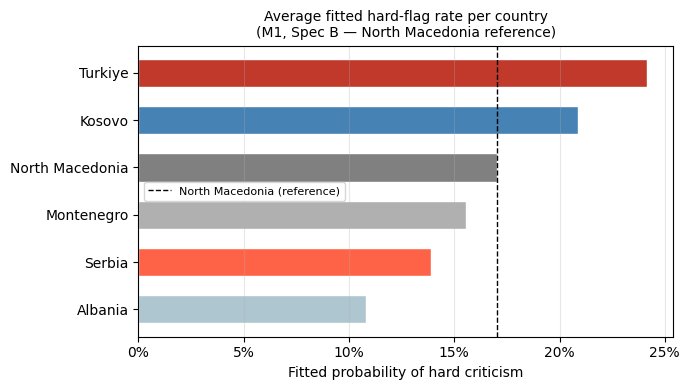

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Fitted vs observed hard-flag rates per country ────────────────────────────
# Predict on the full reg dataframe, then group — avoids patsy context issues
all_fitted = m1.predict(reg)
fitted     = all_fitted.groupby(reg["country"]).mean()
observed   = reg.groupby("country")["hard_flag"].mean()

prob_tbl = pd.DataFrame({
    "Observed rate":   observed,
    "Fitted rate (M1)": fitted,
    "Difference":       fitted - observed,
}).sort_values("Fitted rate (M1)", ascending=False)
prob_tbl = prob_tbl.map(lambda x: f"{x:.1%}")

print("Hard-flag probability per country (M1, North Macedonia reference)")
print(prob_tbl.to_string())

# ── Topic ORs from M1 — clean standalone table ────────────────────────────────
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

topic_idx = [i for i in m1.params.index if i.startswith("topic_")]
topic_or  = np.exp(m1.params[topic_idx])
topic_lo  = np.exp(m1.conf_int().loc[topic_idx, 0])
topic_hi  = np.exp(m1.conf_int().loc[topic_idx, 1])
topic_p   = m1.pvalues[topic_idx]

topic_tbl = pd.DataFrame({
    "Odds Ratio": [f"{v:.3f}{stars(p)}" for v, p in zip(topic_or, topic_p)],
    "95% CI":     [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in zip(topic_lo, topic_hi)],
}, index=[i.replace("topic_", "").replace("_", " ") for i in topic_idx])

print("\nM1 topic effects — hard_flag (OR vs no topic tag, * p<.05 ** p<.01 *** p<.001)")
print(topic_tbl.to_string())

# ── Bar chart: fitted hard-flag probability by country ────────────────────────
prob_num = all_fitted.groupby(reg["country"]).mean().sort_values()
country_colors = {
    "Serbia":          "tomato",
    "Kosovo":          "steelblue",
    "North Macedonia": "grey",
    "Albania":         "#aec6cf",
    "Montenegro":      "#b0b0b0",
    "Turkiye":         "#c0392b",
}
colors = [country_colors.get(c, "grey") for c in prob_num.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(prob_num.index, prob_num.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(prob_num["North Macedonia"], color="black", linewidth=1,
           linestyle="--", label="North Macedonia (reference)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Fitted probability of hard criticism")
ax.set_title("Average fitted hard-flag rate per country\n(M1, Spec B — North Macedonia reference)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6 — Kosovo / Serbia / North Macedonia over time
Line chart using the country-year `agg` dataframe. Plots hard and soft criticism separately to make the Serbia anomaly (high soft, low hard) visually apparent against the North Macedonia baseline. All three countries share full 2019–2025 coverage.

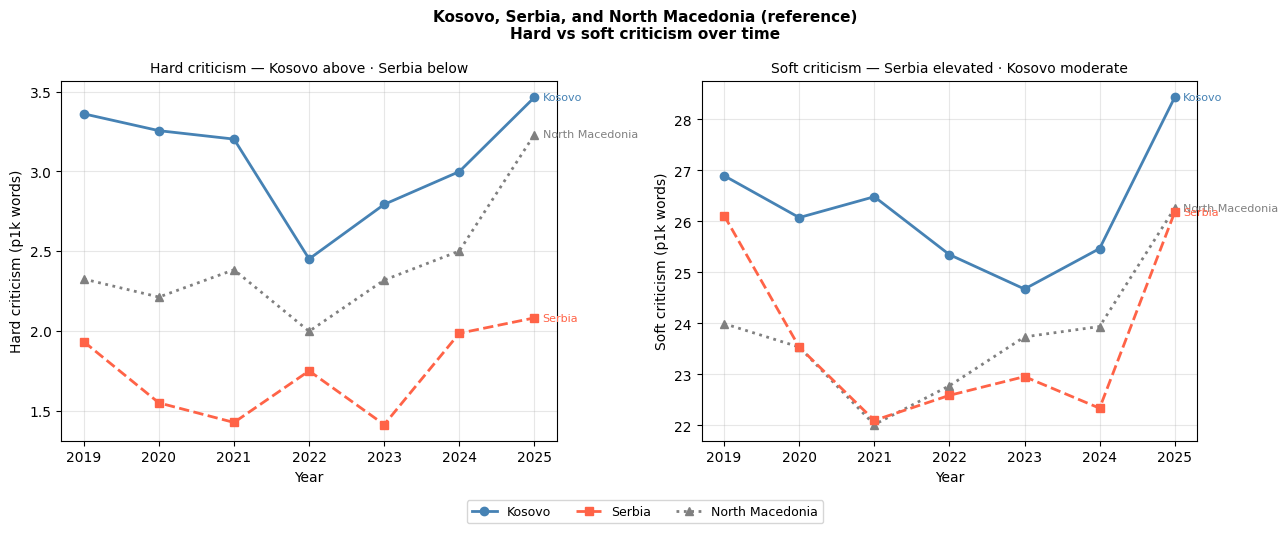

In [9]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

focus  = ["Kosovo", "Serbia", "North Macedonia"]
styles = {"Kosovo":         ("steelblue", "o", "-"),
          "Serbia":         ("tomato",    "s", "--"),
          "North Macedonia":("grey",      "^", ":" )}

sub = agg[agg["country"].isin(focus)].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
panels = [
    (axes[0], "criticism_hard_p1k", "Hard criticism (p1k words)",
     "Hard criticism — Kosovo above · Serbia below"),
    (axes[1], "criticism_soft_p1k", "Soft criticism (p1k words)",
     "Soft criticism — Serbia elevated · Kosovo moderate"),
]

for ax, col, ylabel, title in panels:
    for country, grp in sub.groupby("country"):
        color, marker, ls = styles[country]
        ax.plot(grp["year"], grp[col], color=color, marker=marker,
                linestyle=ls, linewidth=2, markersize=6)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.grid(True, alpha=0.3)

# Annotate 2025 endpoints
for country, grp in sub.groupby("country"):
    color, _, _ = styles[country]
    for col, ax in [(panels[0][1], axes[0]), (panels[1][1], axes[1])]:
        row = grp[grp["year"] == grp["year"].max()]
        if not row.empty:
            ax.annotate(country,
                        xy=(row["year"].values[0], row[col].values[0]),
                        xytext=(6, 0), textcoords="offset points",
                        fontsize=8, color=color, va="center")

legend_handles = [
    mlines.Line2D([], [], color=c, marker=m, linestyle=ls,
                  linewidth=2, markersize=6, label=country)
    for country, (c, m, ls) in styles.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.suptitle("Kosovo, Serbia, and North Macedonia (reference)\nHard vs soft criticism over time",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Step 7 — Serbia "handled with care": scatter analysis

Two scatters at country-year level (6 countries × 7 years = 42 points):

- **Left:** soft criticism (x) vs hard criticism (y) — Serbia should sit in the bottom-right quadrant (high soft, low hard), while Kosovo and Türkiye sit higher. Crosshairs at sample means divide the space into quadrants.
- **Right:** hard criticism (x) vs severity ratio (y) — confirms Serbia's low severity is not just low volume: even relative to its hard criticism level, the ratio is disproportionately low.

Serbia points are labelled by year so you can see whether the anomaly is stable or drifting.

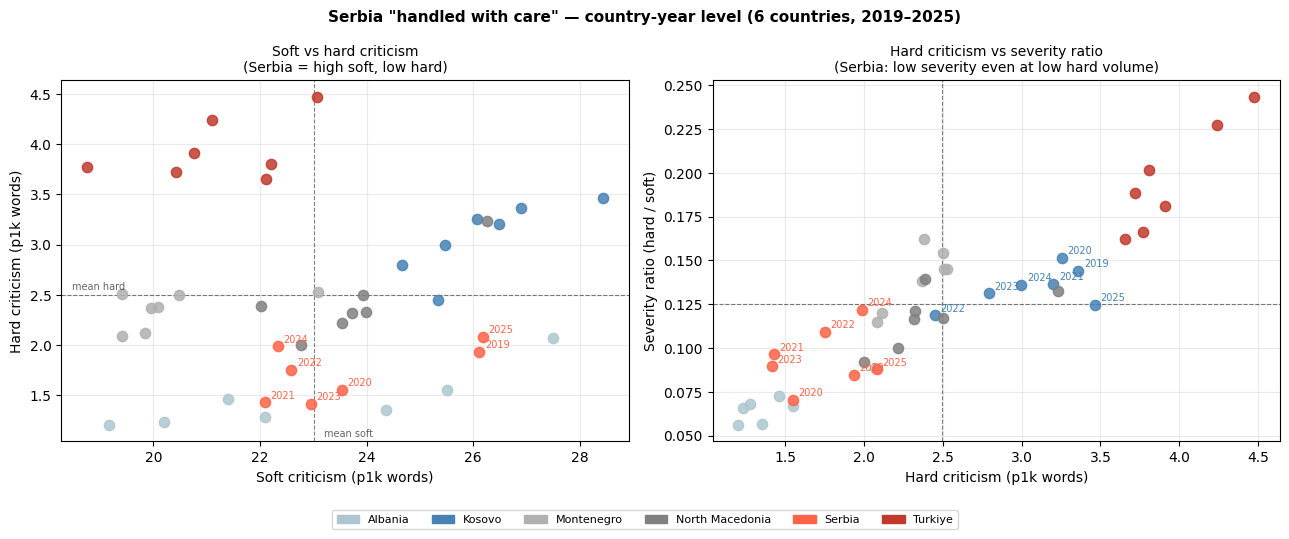

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

full_coverage = ["Albania", "Kosovo", "Montenegro", "North Macedonia", "Serbia", "Turkiye"]
agg_fc = agg[agg["country"].isin(full_coverage)].copy()

country_colors = {
    "Serbia":          "tomato",
    "Kosovo":          "steelblue",
    "Turkiye":         "#c0392b",
    "North Macedonia": "grey",
    "Albania":         "#aec6cf",
    "Montenegro":      "#b0b0b0",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scatter 1: soft (x) vs hard (y) ──────────────────────────────────────────
ax = axes[0]
for country, grp in agg_fc.groupby("country"):
    color = country_colors[country]
    ax.scatter(grp["criticism_soft_p1k"], grp["criticism_hard_p1k"],
               color=color, s=55, zorder=3, alpha=0.85)
    # Label Serbia points by year
    if country == "Serbia":
        for _, row in grp.iterrows():
            ax.annotate(str(int(row["year"])),
                        (row["criticism_soft_p1k"], row["criticism_hard_p1k"]),
                        xytext=(4, 3), textcoords="offset points",
                        fontsize=7, color=color)

# Crosshairs at sample means
xmean = agg_fc["criticism_soft_p1k"].mean()
ymean = agg_fc["criticism_hard_p1k"].mean()
ax.axvline(xmean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(ymean, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(xmean + 0.2, ax.get_ylim()[0] + 0.05, "mean soft", fontsize=7, alpha=0.6)
ax.text(ax.get_xlim()[0] + 0.2, ymean + 0.05, "mean hard", fontsize=7, alpha=0.6)

ax.set_xlabel("Soft criticism (p1k words)")
ax.set_ylabel("Hard criticism (p1k words)")
ax.set_title("Soft vs hard criticism\n(Serbia = high soft, low hard)", fontsize=10)
ax.grid(True, alpha=0.25)

# ── Scatter 2: hard (x) vs severity ratio (y) ────────────────────────────────
ax = axes[1]
for country, grp in agg_fc.groupby("country"):
    color = country_colors[country]
    ax.scatter(grp["criticism_hard_p1k"], grp["severity_ratio"],
               color=color, s=55, zorder=3, alpha=0.85)
    # Label Serbia and Kosovo by year
    if country in ("Serbia", "Kosovo"):
        for _, row in grp.iterrows():
            ax.annotate(str(int(row["year"])),
                        (row["criticism_hard_p1k"], row["severity_ratio"]),
                        xytext=(4, 3), textcoords="offset points",
                        fontsize=7, color=color)

xmean2 = agg_fc["criticism_hard_p1k"].mean()
ymean2 = agg_fc["severity_ratio"].mean()
ax.axvline(xmean2, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(ymean2, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel("Hard criticism (p1k words)")
ax.set_ylabel("Severity ratio (hard / soft)")
ax.set_title("Hard criticism vs severity ratio\n(Serbia: low severity even at low hard volume)", fontsize=10)
ax.grid(True, alpha=0.25)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles = [mpatches.Patch(color=country_colors[c], label=c) for c in full_coverage]
fig.legend(handles=handles, loc="lower center", ncol=6,
           fontsize=8, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('Serbia "handled with care" — country-year level (6 countries, 2019–2025)',
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Conclusion

### Main findings

**1. Topic effects are consistent and substantively coherent.**
Controlling for country and time, paragraphs tagged with *judiciary / rule of law* are nearly twice as likely to contain hard criticism as untagged paragraphs (OR ≈ 1.92); *corruption* is next (OR ≈ 1.64). *Economy / market* is the only protective topic (OR ≈ 0.88) — the EU consistently uses softer, technical language when discussing economic reform. This hierarchy holds across all three DVs and is robust to clustered standard errors.

**2. No time trend.**
The year coefficient is non-significant in all three models. Hard criticism has neither escalated nor declined systematically across 2019–2025 after controlling for country composition and topic. The patterns visible in the raw time series reflect differences in *which countries* are being observed in which years, not a corpus-wide shift in tone.

**3. Three distinct country profiles emerge.**

| Country | Hard flag | Soft flag | Severity ratio | Interpretation |
|---|---|---|---|---|
| **Türkiye** | Highest (OR 1.56) | Average | Highest (+0.078) | High frequency *and* high intensity — the EU escalates directly to hard language |
| **Kosovo** | High (OR 1.28) | Moderately high (OR 1.10) | Near average | Broad coverage across all topics, not especially pointed in any domain |
| **Serbia** | Below average (OR 0.78) | Above average (OR 1.10) | Lowest (−0.026) | "Handled with care" — high volume of soft diplomatic language, systematic avoidance of hard escalation |
| **North Macedonia** | Reference (1.00) | Reference (1.00) | Reference | Mid-pack, stable, consistent with average EU candidate treatment |
| **Albania** | Lowest (OR 0.61) | Below average | Lowest absolute | Least criticism overall; the EU's most favourable Western Balkans framing |

**4. Kosovo's excess is broad, not topic-specific.**
The Kosovo × topic interaction shows that being tagged as *judiciary* is actually a weaker predictor of hard criticism for Kosovo than for other countries (OR = 0.65, p < 0.001). Kosovo's country FE reflects uniform elevation across all domains, not a concentrated problem in any single area. In the restricted 2023–2025 window, Kosovo's hard flag OR shrinks toward the North Macedonia baseline (1.09), suggesting the earlier years (2019–2022) drive most of its distinctiveness.

---

### Limitations

- **Keyword matching does not handle negation** — "did not fail" would be scored as a hit for `failed`. In EU institutional prose this is rare but not impossible.
- **No context window** — a hard criticism term in a subordinate clause ("despite the failure of previous governments...") is treated identically to a direct assessment.
- **Dictionary coverage** — the lexicon was hand-built and may under-count domain-specific terms not present in the initial list. Expansion via word embeddings (e.g. finding nearest neighbours of existing terms in a corpus-trained embedding space) was considered but not implemented.
- **Paragraph as unit** — some country-level assessments span multiple paragraphs; single-paragraph scoring may fragment coherent arguments.
- **Unbalanced panel** — Georgia, Moldova, Ukraine, and Bosnia are only observed from 2020–2025 or 2023–2025. Their full-sample fixed effects conflate country and period effects; the restricted 2023–2025 robustness check addresses this for the core six countries.

---

### NLP approaches considered but not used

| Approach | Reason not adopted |
|---|---|
| Supervised classification (e.g. fine-tuned BERT) | Requires labelled training data; labels would themselves be subjective |
| Sentiment analysis (VADER, TextBlob) | General-purpose sentiment does not map onto EU bureaucratic register |
| Topic modelling (LDA / NMF) | Produces unstable topics without domain priors; less interpretable for a policy audience |
| Word embeddings for dictionary expansion | Could improve recall; flagged for future work |
| Transformer zero-shot classification | Promising but computationally intensive; dictionary approach sufficient for this scope |